In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import sys
import math
import shap

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
Q = 'Q1'
q = 'q1'

In [4]:
file1 = f'../data/CMacedonia/{NUTS0}_CMacedonia_WNV_Dataset_{Q}_2011_2022.csv'
file2 = f'../data/Attica/{NUTS0}_Attica_WNV_Dataset_{Q}_2011_2022.csv'
file3 = f'../data/Thessaly/{NUTS0}_Thessaly_WNV_Dataset_{Q}_2011_2022.csv'

dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)

In [5]:
dataset1.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,6.229173,9.327499,7.851225,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.253413,0.164233,0.382909,-0.382909,0.243740,0.189907,0.401026,-0.401026,0.044376,0.051454,0.050562,0.050562,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.25,5025.2,5265.4,18028.909091,1
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,6.833876,9.632381,7.258680,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.331371,-0.125325,0.181410,-0.181410,0.328781,-0.127656,0.175605,-0.175605,0.053834,0.060592,0.055271,0.055271,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.51,9804.6,10058.8,16320.850394,1
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,7.183375,10.120540,4.959644,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.238927,-0.089832,0.144111,-0.144111,0.241070,-0.091286,0.144951,-0.144951,0.023444,0.040297,0.033327,0.033327,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.52,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,6.643856,9.787595,6.495086,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.257757,0.126741,0.363656,-0.363656,0.254301,0.126465,0.361181,-0.361181,0.039384,0.052719,0.050437,0.050437,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.34,5025.2,5265.4,15360.034091,1
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,6.992178,8.838208,9.737422,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.269825,0.101198,0.347946,-0.347946,0.258944,0.119827,0.353585,-0.353585,0.044928,0.065635,0.063431,0.063431,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.03,5025.2,5265.4,18910.088889,0


In [6]:
dataset2.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,8.777903,10.142834,12.225479,21.632204,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,0.255745,-0.142293,0.107329,-0.107329,0.253581,-0.144536,0.102359,-0.102359,0.036118,0.024477,0.025483,0.025483,293537.0,45883.0,200375.0,47279.0,324283.0,43595.0,220412.0,60276.0,18689.14,2605.2,3841.2,17366.277778,1
1,2011,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,9.456237,11.021415,13.184319,22.222381,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,0.245740,-0.156439,0.090184,-0.090184,0.216751,-0.157282,0.070787,-0.070787,0.024685,0.016912,0.012720,0.012720,252508.0,38921.0,179791.0,33796.0,259441.0,36714.0,177899.0,44828.0,7131.89,2605.2,3841.2,22230.111111,1
2,2011,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,9.503973,10.862909,12.827836,21.453654,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,0.214027,-0.102015,0.097905,-0.097905,0.208985,-0.095366,0.098232,-0.098232,0.046665,0.032105,0.029402,0.029402,521694.0,64868.0,377784.0,79042.0,569144.0,61544.0,388717.0,118883.0,39021.83,2605.2,3841.2,19777.421053,1
3,2011,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,9.247935,10.805057,12.688842,21.449134,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,0.224800,-0.150127,0.074458,-0.074458,0.208431,-0.137764,0.072454,-0.072454,0.033418,0.027221,0.023599,0.023599,263293.0,38993.0,183267.0,41033.0,291408.0,36789.0,199070.0,55549.0,12606.74,2605.2,3841.2,21091.900000,1
4,2011,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,8.145652,9.352691,11.222872,22.115978,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,0.403031,-0.207276,0.160501,-0.160501,0.392773,-0.193846,0.163102,-0.163102,0.034937,0.036822,0.034206,0.034206,259185.0,43417.0,180372.0,35396.0,252043.0,41239.0,171976.0,38828.0,13091.44,2605.2,3841.2,15911.479310,1


In [7]:
dataset3.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,3.686851,5.948136,8.265869,14.428439,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,0.247676,0.124756,0.332002,-0.332002,0.250039,0.109395,0.319940,-0.319940,0.050979,0.086203,0.061957,0.061957,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.13,10080.6,10176.8,5230.598616,1
1,2011,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,4.875334,7.672218,10.319188,10.048595,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.294055,0.019309,0.273389,-0.273389,0.299809,0.018538,0.280083,-0.280083,0.042559,0.047435,0.047199,0.047199,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.45,6268.6,6460.0,4285.480144,1
2,2011,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,5.750763,8.008002,10.354182,15.117940,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.337567,0.009852,0.289970,-0.289970,0.329326,0.020087,0.296028,-0.296028,0.046129,0.075248,0.053855,0.053855,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.99,6268.6,6460.0,2948.510417,1
3,2012,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1.038181,4.630964,10.593495,14.288565,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,0.218565,0.035023,0.214999,-0.214999,0.210467,0.056554,0.228696,-0.228696,0.049441,0.090672,0.068613,0.068613,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.51,10080.6,10176.8,5014.138408,0
4,2012,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2.947811,6.688539,12.883651,9.134991,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,0.227105,-0.092324,0.108107,-0.108107,0.228260,-0.110236,0.093846,-0.093846,0.048894,0.066280,0.057066,0.057066,143171.0,23273.0,93519.0,26379.0,147118.0,22079.0,93390.0,31649.0,4125.73,6268.6,6460.0,4641.090253,0


In [8]:
dataset = pd.concat([dataset1, dataset2, dataset3])

In [9]:
dataset

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,6.229173,9.327499,7.851225,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.253413,0.164233,0.382909,-0.382909,0.243740,0.189907,0.401026,-0.401026,0.044376,0.051454,0.050562,0.050562,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.250,5025.2,5265.4,18028.909091,1
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,6.833876,9.632381,7.258680,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.331371,-0.125325,0.181410,-0.181410,0.328781,-0.127656,0.175605,-0.175605,0.053834,0.060592,0.055271,0.055271,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.510,9804.6,10058.8,16320.850394,1
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,7.183375,10.120540,4.959644,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.238927,-0.089832,0.144111,-0.144111,0.241070,-0.091286,0.144951,-0.144951,0.023444,0.040297,0.033327,0.033327,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.520,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,6.643856,9.787595,6.495086,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.257757,0.126741,0.363656,-0.363656,0.254301,0.126465,0.361181,-0.361181,0.039384,0.052719,0.050437,0.050437,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.340,5025.2,5265.4,15360.034091,1
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,6.992178,8.838208,9.737422,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.269825,0.101198,0.347946,-0.347946,0.258944,0.119827,0.353585,-0.353585,0.044928,0.065635,0.063431,0.063431,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.030,5025.2,5265.4,18910.088889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,6.581947,7.403107,12.675841,18.250000,22.166667,47.163121,871.388651,44.0,-3.0,47.0,10.000000,25.833333,28.333333,7.333333,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.382134,-0.332549,0.126803,-0.126803,0.366238,-0.319081,0.127453,-0.127453,0.060245,0.050407,0.065043,0.065043,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3078.914,2621.0,2977.0,11643.101083,1
162,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,6.581947,7.403107,12.675841,18.250000,22.166667,47.163121,871.388651,44.0,-3.0,47.0,10.000000,25.833333,28.333333,7.333333,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.382134,-0.332549,0.126803,-0.126803,0.366238,-0.319081,0.127453,-0.127453,0.060245,0.050407,0.065043,0.065043,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3078.914,2621.0,2977.0,11643.101083,1
163,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,6.581947,7.403107,12.675841,18.250000,22.

In [10]:
dataset.columns

Index(['year', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y',
       'min_temp_q1', 'mean_temp_q1', 'max_temp_q1', 'prec_q1', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q1', 'ndwi_q1', 'ndmi_q1', 'ndbi_q1', 'ndvi_mean_q1',
       'ndwi_mean_q1', 'ndmi_mean_q1', 'ndbi_mean_q1', 'ndvi_std_q1',
       'ndwi_std_q1', 'ndmi_std_q1', 'ndbi_std_q1', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'culex_pipiens', 'WNV_cases'],
      dtype='object')

In [11]:
print(f'Number of NUTS3 Units in dataset: {len(dataset.NUTS3_NAME.unique())}')

Number of NUTS3 Units in dataset: 17


In [12]:
dsc = dataframe_describe(dataset, target_column = 'WNV_cases')
dsc.head(15)

,year,non-case,case,total,percentage
0,2011,2,91,93,7.96%
1,2012,8,65,73,6.24%
2,2013,9,56,65,5.56%
3,2014,16,2,18,1.54%
4,2015,17,0,17,1.45%
5,2016,17,0,17,1.45%
6,2017,17,0,17,1.45%
7,2018,2,279,281,24.04%
8,2019,5,130,135,11.55%
9,2020,7,105,112,9.58%


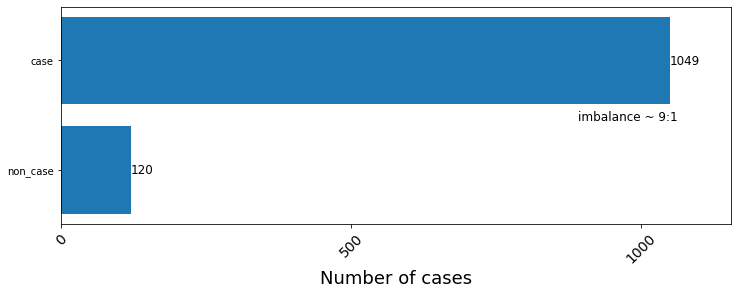

In [13]:
plot_imbalance(dataset, target_column='WNV_cases')

In [14]:
r_u = 0
near_u = 0
smote = 0
scaler = 'minmax'
weight_multiplier = 1

years_to_remove = [2020, 2021, 2022]
features_to_remove = ['x', 'y', 'year']
#features_to_remove=[]
#years_to_remove = []

In [15]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'] + features_to_remove).columns

In [16]:

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
x = dataset.drop(columns = ['WNV_cases'])
y = dataset['WNV_cases']
fold = 0
  
for train_idx, test_idx in skf.split(x, y):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    data_test = data_test.drop_duplicates(keep='first')
    if len(years_to_remove) > 0:
        data_train = data_train.loc[~data_train['year'].isin(years_to_remove)]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'])
    y_train = data_train['WNV_cases']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'])
    y_test = data_test['WNV_cases']
    
    X_train, X_test, y_train, y_test, X_train_df, scaler, imputer = transform_data_new(X_train, X_test, y_train, y_test, r_u, near_u, smote, majority_class = 1, scaler_key=scaler, exclude_features=features_to_remove)
    w0,w1 = calculate_weights_new(y_train)
    w1 = w1*weight_multiplier

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model = train_lin_model(model, X_train, y_train)

    masker = shap.maskers.Independent(data = X_train)
    explainer = shap.LinearExplainer(trained_model, masker = masker)
    shap_values = explainer.shap_values(X_train)
    
    train, test, coef = predict_lin_model(trained_model, X_train_df, data_test, X_train, y_train, X_test, y_test, day_col = None, month_col = None, spatial_col = 'NUTS3_NAME')
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Fold: {fold} || w0:{w0}, w1:{w1} || ##")
    fold = fold + 1

Fold: 0 || w0:7, w1:1 || ##
Fold: 1 || w0:7, w1:1 || ##
Fold: 2 || w0:7, w1:1 || ##
Fold: 3 || w0:7, w1:1 || ##
Fold: 4 || w0:7, w1:1 || ##
Fold: 5 || w0:7, w1:1 || ##
Fold: 6 || w0:7, w1:1 || ##
Fold: 7 || w0:7, w1:1 || ##
Fold: 8 || w0:7, w1:1 || ##
Fold: 9 || w0:7, w1:1 || ##


In [17]:
results_test.sort_values(by=['score'], ascending = False, ignore_index = True, inplace = True)

In [18]:
results_test

,x,y,NUTS3_NAME,year,case,score
0,23.139532,40.695359,θεσσαλονικη,2012,1,0.963179
1,23.139532,40.695359,θεσσαλονικη,2011,1,0.954580
2,23.139532,40.695359,θεσσαλονικη,2012,1,0.950625
3,23.139532,40.695359,θεσσαλονικη,2012,1,0.945781
4,22.215876,40.552658,ημαθια,2018,1,0.942735
...,...,...,...,...,...,...
554,21.719540,39.504234,"καρδιτσα, τρικαλα",2014,0,0.021005
555,23.542098,41.085750,σερρες,2015,0,0.016359
556,22.441443,40.269748,πιερια,2015,0,0.014414
557,22.215876,40.552658,ημαθια,2015,0,0.013459


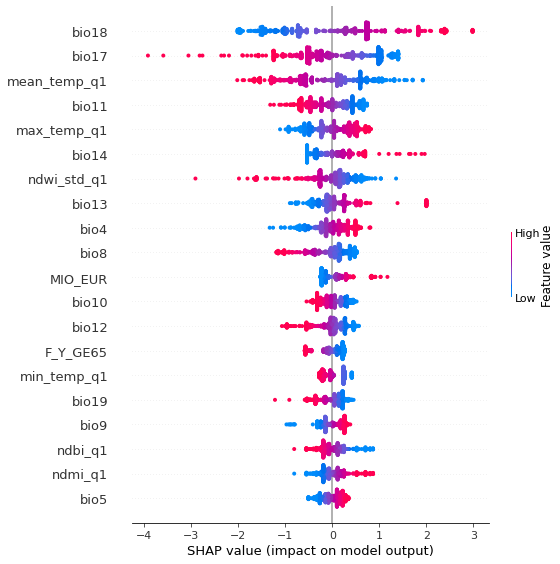

In [19]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names)

In [20]:
shap_values.shape

(652, 47)

In [21]:
feature_names.shape

(47,)

In [22]:
X_train.shape

(652, 47)

In [23]:
mean_shap_values = shap_values.mean(axis=0)

In [24]:
mean_shap_values.shape

(47,)

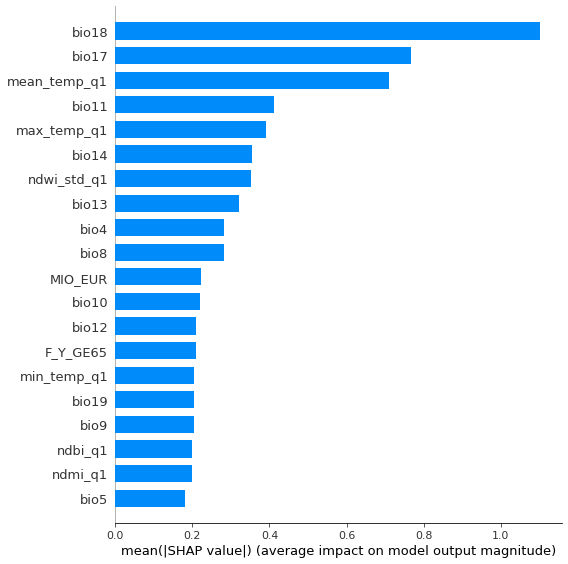

In [25]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar')

In [26]:
mean_shap_values = shap_values.mean(axis=0)

ft_importance = pd.DataFrame()

for i in range(len(feature_names)):
    ft_importance = ft_importance.append({'Feature': feature_names[i],
                                          'Shap': mean_shap_values[i]}, ignore_index = True)

ft_importance.sort_values(by='Shap', key=pd.Series.abs, inplace = True, ascending = False)

ft_importance.head()

,Feature,Shap
1,mean_temp_q1,-0.124978
20,bio17,0.064131
16,bio13,0.059002
14,bio11,-0.058860
32,ndwi_std_q1,0.054656


In [27]:
ft_importance['Shap_Abs'] = ft_importance['Shap'].apply(lambda x: abs(x))

In [28]:
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']
climate = [f'min_temp_{q}', f'mean_temp_{q}', f'max_temp_{q}', f'prec_{q}']
enviromental = [f'ndvi_{q}',f'ndwi_{q}',f'ndmi_{q}',f'ndbi_{q}',f'ndvi_mean_{q}',f'ndwi_mean_{q}',f'ndmi_mean_{q}',f'ndbi_mean_{q}',f'ndvi_std_{q}',f'ndwi_std_{q}',f'ndmi_std_{q}',f'ndbi_std_{q}']
demographic = ['M_TOTAL','M_Y_LT_15','M_Y15-64','M_Y_GE65','F_TOTAL','F_Y_LT_15','F_Y15-64','F_Y_GE65']
vectors = ['culex_pipiens']
trade = ['L_TOTAL',	'UNL_TOTAL']
economic = ['MIO_EUR']

df_bioclimatic = ft_importance.loc[ft_importance['Feature'].isin(bioclimatic)].drop(columns=['Shap'])
df_climate = ft_importance.loc[ft_importance['Feature'].isin(climate)].drop(columns=['Shap'])
df_enviromental = ft_importance.loc[ft_importance['Feature'].isin(enviromental)].drop(columns=['Shap'])
df_demographic = ft_importance.loc[ft_importance['Feature'].isin(demographic)].drop(columns=['Shap'])
df_vectors = ft_importance.loc[ft_importance['Feature'].isin(vectors)].drop(columns=['Shap'])
df_trade = ft_importance.loc[ft_importance['Feature'].isin(trade)].drop(columns=['Shap'])
df_economic = ft_importance.loc[ft_importance['Feature'].isin(economic)].drop(columns=['Shap'])

In [29]:
categories = {'Category': ['bioclimatic', 'climate', 'enviromental', 'demographic', 'vectors', 'trade', 'economic'], 
              'Mean_Shap': [df_bioclimatic.Shap_Abs.sum(),df_climate.Shap_Abs.sum(),df_enviromental.Shap_Abs.sum(),
                            df_demographic.Shap_Abs.sum(),df_vectors.Shap_Abs.sum(),df_trade.Shap_Abs.sum(),df_economic.Shap_Abs.sum()]}

In [30]:
categories_df = pd.DataFrame.from_dict(categories)

In [31]:
categories_df.sort_values(by = 'Mean_Shap', ascending=False)

,Category,Mean_Shap
0,bioclimatic,0.387218
1,climate,0.177718
2,enviromental,0.090127
3,demographic,0.056855
4,vectors,0.038598
6,economic,0.020468
5,trade,0.000348


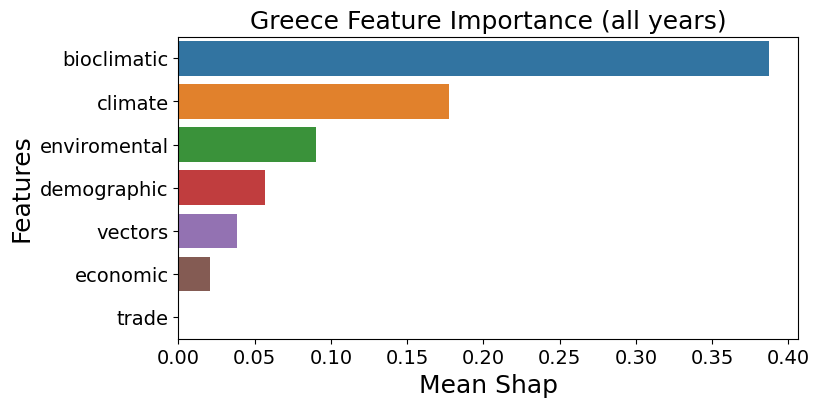

In [32]:
mean_shap = categories_df['Mean_Shap']
mean_shap = mean_shap.to_numpy().reshape(1,7)

plot_feature_importance(mean_shap, categories_df['Category'], x_label = 'Mean Shap', title = f'Greece Feature Importance (all years)', title_size=18, figure_size = (8, 4))

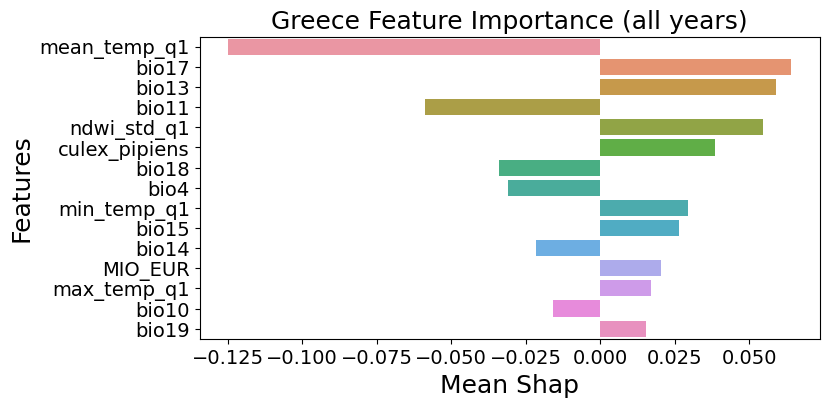

In [33]:
mean_shap = ft_importance['Shap']
shp = mean_shap.shape[0]
mean_shap = mean_shap.to_numpy().reshape(1,shp)

plot_feature_importance(mean_shap, ft_importance['Feature'], x_label = 'Mean Shap', title = f'Greece Feature Importance (all years)', title_size=18, top = 15, figure_size = (8, 4))

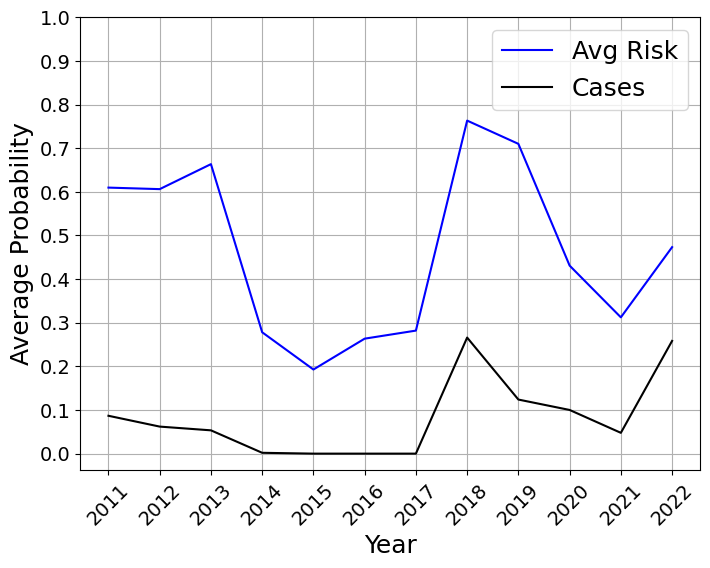

In [34]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']))

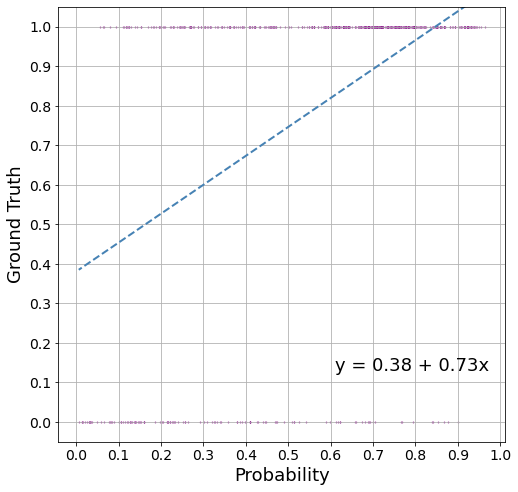

In [35]:
plot_probability_curve(results_test)

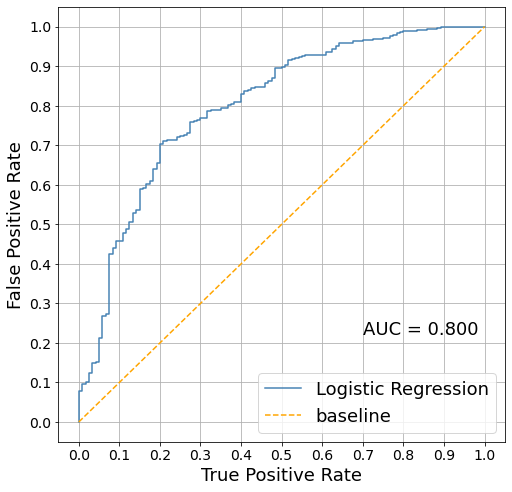

In [36]:
plot_roc_curve(results_test)

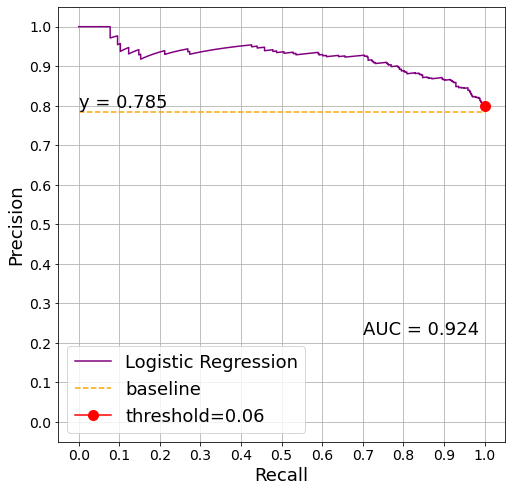

In [37]:
plot_pr_curve(results_test, plot_fbeta=True)

In [38]:
results_test

,x,y,NUTS3_NAME,year,case,score
0,23.139532,40.695359,θεσσαλονικη,2012,1,0.963179
1,23.139532,40.695359,θεσσαλονικη,2011,1,0.954580
2,23.139532,40.695359,θεσσαλονικη,2012,1,0.950625
3,23.139532,40.695359,θεσσαλονικη,2012,1,0.945781
4,22.215876,40.552658,ημαθια,2018,1,0.942735
...,...,...,...,...,...,...
554,21.719540,39.504234,"καρδιτσα, τρικαλα",2014,0,0.021005
555,23.542098,41.085750,σερρες,2015,0,0.016359
556,22.441443,40.269748,πιερια,2015,0,0.014414
557,22.215876,40.552658,ημαθια,2015,0,0.013459


In [39]:
results_test['pred_01'] = results_test['score'].apply(lambda x: 1 if x>= 0.1 else 0)
results_test['pred_02'] = results_test['score'].apply(lambda x: 1 if x>= 0.2 else 0)
results_test['pred_05'] = results_test['score'].apply(lambda x: 1 if x>= 0.5 else 0)

In [40]:
results_test

,x,y,NUTS3_NAME,year,case,score,pred_01,pred_02,pred_05
0,23.139532,40.695359,θεσσαλονικη,2012,1,0.963179,1,1,1
1,23.139532,40.695359,θεσσαλονικη,2011,1,0.954580,1,1,1
2,23.139532,40.695359,θεσσαλονικη,2012,1,0.950625,1,1,1
3,23.139532,40.695359,θεσσαλονικη,2012,1,0.945781,1,1,1
4,22.215876,40.552658,ημαθια,2018,1,0.942735,1,1,1
...,...,...,...,...,...,...,...,...,...
554,21.719540,39.504234,"καρδιτσα, τρικαλα",2014,0,0.021005,0,0,0
555,23.542098,41.085750,σερρες,2015,0,0.016359,0,0,0
556,22.441443,40.269748,πιερια,2015,0,0.014414,0,0,0
557,22.215876,40.552658,ημαθια,2015,0,0.013459,0,0,0


In [41]:
accuracy_01 = accuracy_score(results_test.case, results_test.pred_01)
balanced_accuracy_01 = balanced_accuracy_score(results_test.case, results_test.pred_01)
fb_score_01 = fbeta_score(results_test.case, results_test.pred_01, beta = 1, labels = [0,1], zero_division = 0)
precision_01 = precision_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
recall_01 = recall_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
#log_loss_test_01 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [42]:
accuracy_02 = accuracy_score(results_test.case, results_test.pred_02)
balanced_accuracy_02 = balanced_accuracy_score(results_test.case, results_test.pred_02)
fb_score_02 = fbeta_score(results_test.case, results_test.pred_02, beta = 1, labels = [0,1], zero_division = 0)
precision_02 = precision_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
recall_02 = recall_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
#log_loss_test_02 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [43]:
accuracy_05 = accuracy_score(results_test.case, results_test.pred_05)
balanced_accuracy_05 = balanced_accuracy_score(results_test.case, results_test.pred_05)
fb_score_05 = fbeta_score(results_test.case, results_test.pred_05, beta = 1, labels = [0,1], zero_division = 0)
precision_05 = precision_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
recall_05 = recall_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
#log_loss_test_03 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [44]:
thr_01 = {'accuracy': accuracy_01, 'balanced_accuracy': balanced_accuracy_01, 
          'f1_score': fb_score_01, 'precision': precision_01, 'recall': recall_01}

thr_02 = {'accuracy': accuracy_02, 'balanced_accuracy': balanced_accuracy_02, 
          'f1_score': fb_score_02, 'precision': precision_02, 'recall': recall_02}

thr_05 = {'accuracy': accuracy_05, 'balanced_accuracy': balanced_accuracy_05, 
          'f1_score': fb_score_05, 'precision': precision_05, 'recall': recall_05}

In [45]:
results_df = pd.DataFrame([thr_01, thr_02, thr_05])
results_df.index = ['Threshold: 0.1', 'Threshold: 0.2', 'Threshold: 0.5']

In [46]:
results_df

,accuracy,balanced_accuracy,f1_score,precision,recall
Threshold: 0.1,0.812165,0.577639,0.892086,0.812734,0.988610
Threshold: 0.2,0.817531,0.656748,0.889849,0.845996,0.938497
Threshold: 0.5,0.728086,0.739076,0.806122,0.915942,0.719818
